# Atlas-v1 cross-size synthesis: 8 head families × 4 Pythia sizes

Brings together the per-size atlas-v1 sweeps at Pythia-70M / 160M / 410M / 2.8B
(40 §H2-1 checkpoints each) to compare emergence of the 8 head families across model
scale. Pythia-1B excluded per §H4-1 (head-count regression: 128 heads vs. 410m's 384).

**Sizes and head counts:**

| size | layers | heads/layer | total heads |
|---|---:|---:|---:|
| 70m | 6 | 8 | 48 |
| 160m | 12 | 12 | 144 |
| 410m | 24 | 16 | 384 |
| 2.8b | 32 | 32 | 1024 |

All thresholds inherited from 410M calibration for cross-size comparability.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.locked_thresholds import INDUCTION_QK, SUCCESSOR_LIFT, S_INHIBITION_DELTA

FIG_DIR = REPO / "notebooks" / "figures" / "atlas_v1" / "cross_size"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SIZES = ["70m", "160m", "410m", "2.8b"]
SIZE_FS = {"70m": "70m", "160m": "160m", "410m": "410m", "2.8b": "2_8b"}
TOTAL_HEADS = {"70m": 48, "160m": 144, "410m": 384, "2.8b": 1024}
SIZE_COLOR = {"70m": "tab:blue", "160m": "tab:orange", "410m": "tab:green", "2.8b": "tab:purple"}

# Load each size's atlas parquet
atlas_by_size = {}
for sz in SIZES:
    p = REPO / "data" / "atlas" / f"atlas_v1_{SIZE_FS[sz]}_sweep.parquet"
    atlas_by_size[sz] = pd.read_parquet(p)
    print(f"  {sz}: {len(atlas_by_size[sz]):,} rows, motifs={sorted(atlas_by_size[sz]['motif'].unique())}")

# Load locked-motif sweeps; consolidate to a per-size dict
LOCKED_PARQUETS = {
    "induction":    ["phase2_induction_sweep.parquet", "phase4_2_8b_induction_sweep.parquet"],
    "successor":    ["phase2_successor_sweep.parquet", "phase4_2_8b_successor_sweep.parquet"],
    "s_inhibition": ["phase2_s_inhibition_sweep.parquet",
                     "phase4_2_8b_s_inhibition_supersede_sweep.parquet",
                     "phase4_2_8b_s_inhibition_fullgrid_sweep.parquet"],
}

def _load_locked_for_size(motif: str, size: str) -> pd.DataFrame:
    pieces = []
    for fname in LOCKED_PARQUETS[motif]:
        p = REPO / "data" / "exploration" / fname
        if not p.exists():
            continue
        df = pd.read_parquet(p)
        if "size" in df.columns:
            df = df[df["size"] == size]
        if df.empty:
            continue
        pieces.append(df[["size", "step", "layer", "head", "score"]])
    if not pieces:
        return pd.DataFrame(columns=["size", "step", "layer", "head", "motif", "score"])
    df = pd.concat(pieces, ignore_index=True).drop_duplicates(["size", "step", "layer", "head"], keep="first")
    df["motif"] = motif
    return df[["size", "step", "layer", "head", "motif", "score"]]


locked_by_size = {}
for sz in SIZES:
    parts = [_load_locked_for_size(m, sz) for m in ["induction", "successor", "s_inhibition"]]
    locked_by_size[sz] = pd.concat([p for p in parts if not p.empty], ignore_index=True) if any(not p.empty for p in parts) else pd.DataFrame()
    print(f"  {sz} locked: {len(locked_by_size[sz]):,} rows")

# Combine into one dataframe keyed by size + motif
combined_by_size = {}
for sz in SIZES:
    atlas_sz = atlas_by_size[sz][["size", "step", "layer", "head", "motif", "score"]]
    locked_sz = locked_by_size[sz]
    combined_by_size[sz] = pd.concat([locked_sz, atlas_sz], ignore_index=True) if not locked_sz.empty else atlas_sz

THRESHOLDS = {
    "induction":         (INDUCTION_QK.value,       INDUCTION_QK.comparator),
    "successor":         (SUCCESSOR_LIFT.value,     SUCCESSOR_LIFT.comparator),
    "s_inhibition":      (S_INHIBITION_DELTA.value, S_INHIBITION_DELTA.comparator),
    "previous_token":    (0.20, "ge"),
    "duplicate_token":   (0.20, "ge"),
    "positional_offset": (0.15, "ge"),
    "bos_attention":     (0.50, "ge"),
    "delimiter":         (0.40, "ge"),
}

MOTIF_ORDER = [
    "induction", "successor", "s_inhibition",
    "previous_token", "duplicate_token", "positional_offset",
    "bos_attention", "delimiter",
]
MOTIF_COLORS = {
    "induction":         "#1f77b4",
    "successor":         "#ff7f0e",
    "s_inhibition":      "#2ca02c",
    "previous_token":    "#d62728",
    "duplicate_token":   "#9467bd",
    "positional_offset": "#8c564b",
    "bos_attention":     "#e377c2",
    "delimiter":         "#17becf",
}


def pass_count_traj(df: pd.DataFrame, motif: str) -> pd.Series:
    thr_val, op = THRESHOLDS[motif]
    sub = df[df["motif"] == motif]
    if op == "gt":
        per = sub.groupby("step").apply(lambda g: int((g["score"] > thr_val).sum()), include_groups=False)
    else:
        per = sub.groupby("step").apply(lambda g: int((g["score"] >= thr_val).sum()), include_groups=False)
    return per.sort_index()


  70m: 9,600 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'positional_offset', 'previous_token']
  160m: 28,800 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'positional_offset', 'previous_token']
  410m: 76,800 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'positional_offset', 'previous_token']
  2.8b: 204,800 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'positional_offset', 'previous_token']
  70m locked: 5,760 rows
  160m locked: 17,280 rows
  410m locked: 46,080 rows
  2.8b locked: 114,688 rows


## §1. Per-family trajectories across 4 sizes

Each subplot = one head family. Each curve in the subplot = one Pythia size. Shows how the
family's pass-count evolves over training at each scale.


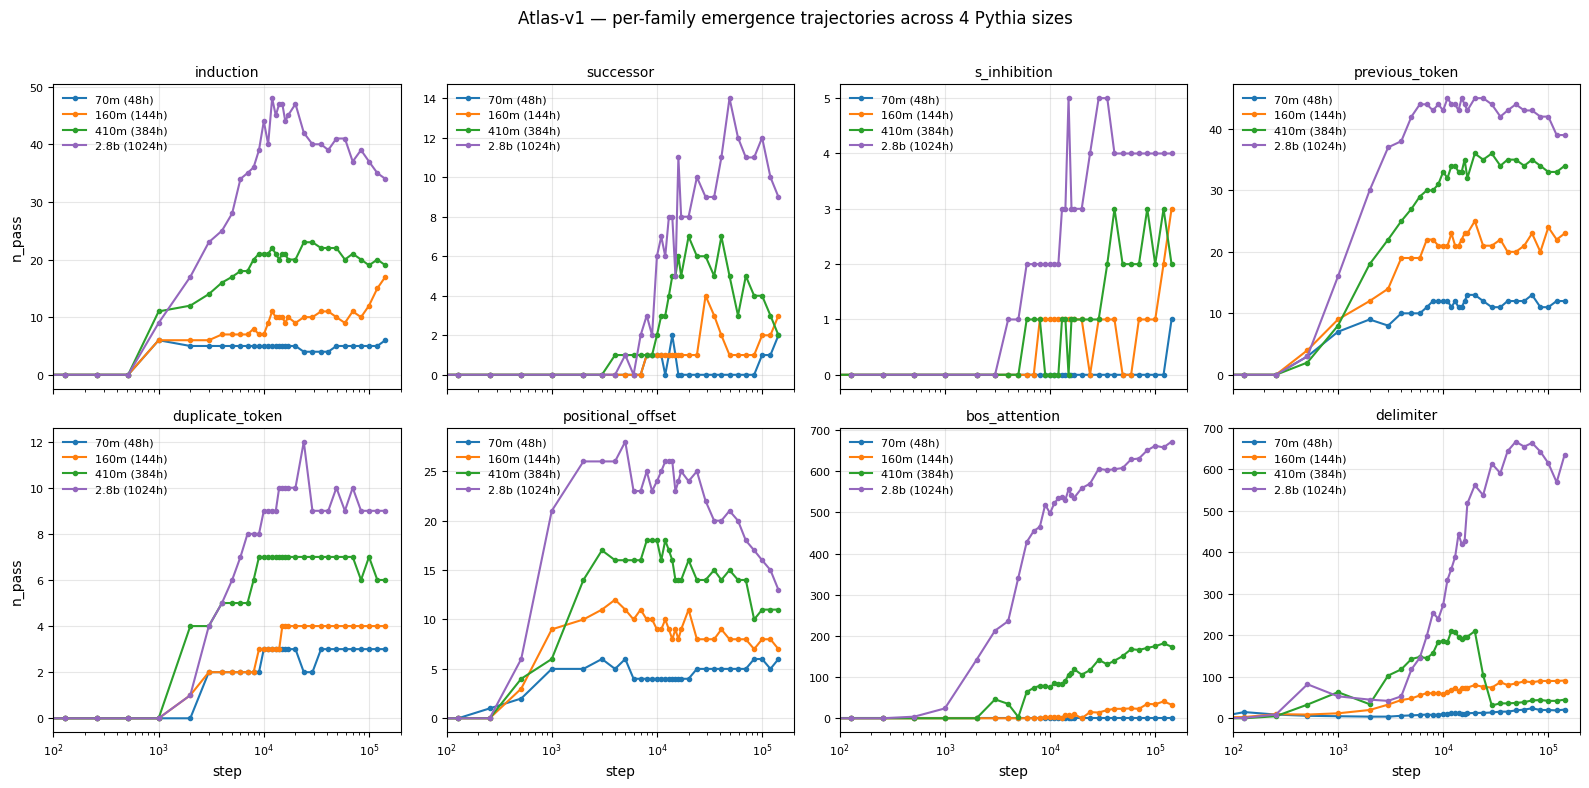

saved notebooks/figures/atlas_v1/cross_size/C1_per_family_4size_trajectories.png


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
for ax, motif in zip(axes.flatten(), MOTIF_ORDER):
    for sz in SIZES:
        if motif not in combined_by_size[sz]["motif"].values:
            continue
        traj = pass_count_traj(combined_by_size[sz], motif)
        if len(traj) == 0:
            continue
        ax.plot(traj.index.values + 1, traj.values, "o-",
                color=SIZE_COLOR[sz], linewidth=1.5, markersize=3,
                label=f"{sz} ({TOTAL_HEADS[sz]}h)")
    ax.set_xscale("log")
    ax.set_xlim(100, 200_000)
    ax.set_title(motif, fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper left", frameon=False)
for ax in axes[1, :]:
    ax.set_xlabel("step")
for ax in axes[:, 0]:
    ax.set_ylabel("n_pass")
fig.suptitle("Atlas-v1 — per-family emergence trajectories across 4 Pythia sizes", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(FIG_DIR / "C1_per_family_4size_trajectories.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'C1_per_family_4size_trajectories.png').relative_to(REPO)}")


## §2. Density-normalized trajectories

Same as §1 but pass-counts normalized to `n_pass / total_heads`. Removes the head-count
scaling effect — reveals whether the family's *density* (fraction of heads) grows or shrinks
with model size.


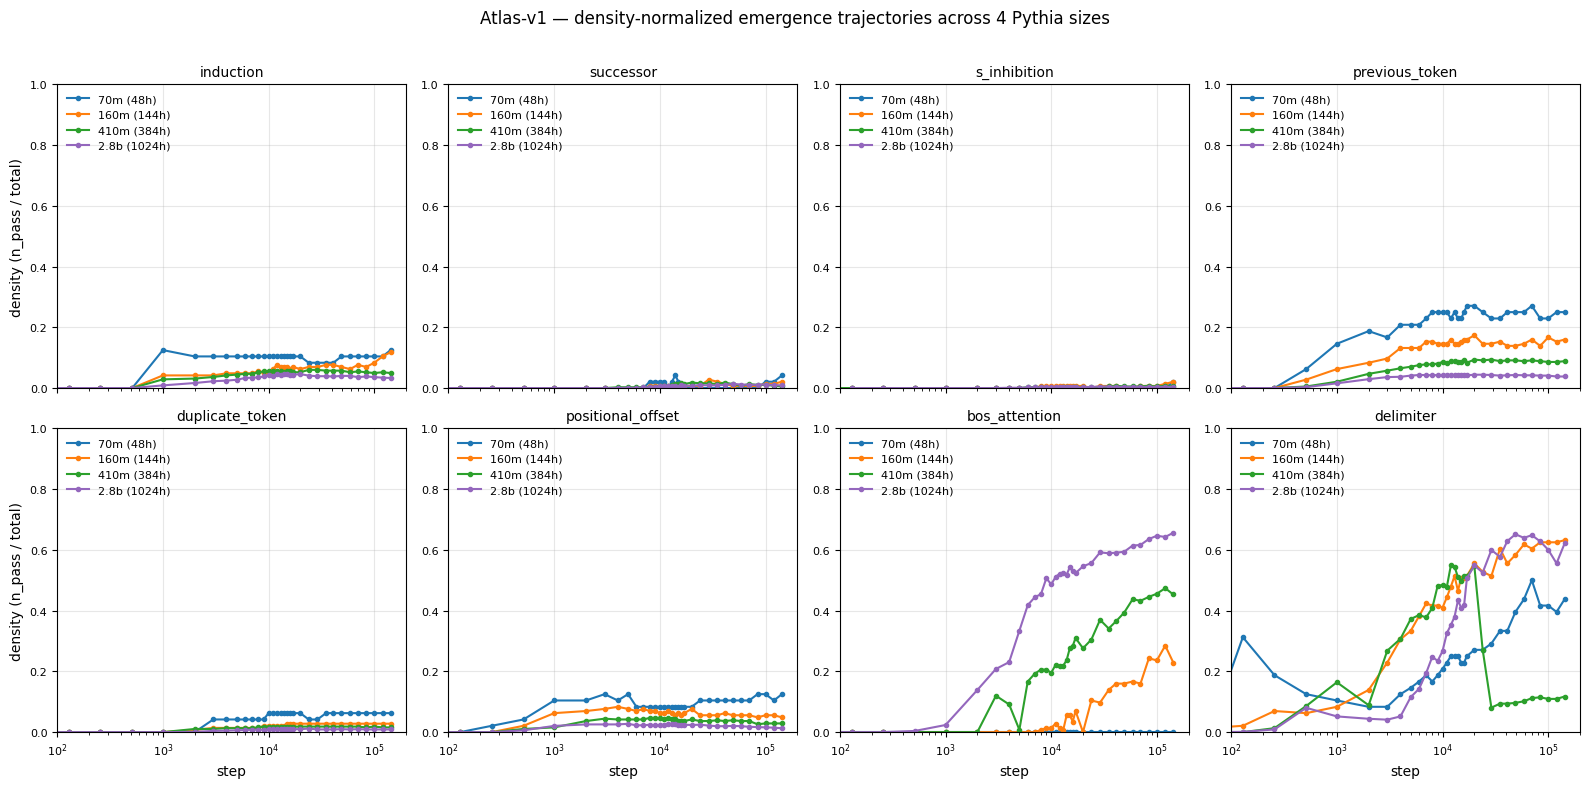

saved notebooks/figures/atlas_v1/cross_size/C2_density_normalized_trajectories.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
for ax, motif in zip(axes.flatten(), MOTIF_ORDER):
    for sz in SIZES:
        if motif not in combined_by_size[sz]["motif"].values:
            continue
        traj = pass_count_traj(combined_by_size[sz], motif)
        if len(traj) == 0:
            continue
        density = traj.values / TOTAL_HEADS[sz]
        ax.plot(traj.index.values + 1, density, "o-",
                color=SIZE_COLOR[sz], linewidth=1.5, markersize=3,
                label=f"{sz} ({TOTAL_HEADS[sz]}h)")
    ax.set_xscale("log")
    ax.set_xlim(100, 200_000)
    ax.set_ylim(0, 1)
    ax.set_title(motif, fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper left", frameon=False)
for ax in axes[1, :]:
    ax.set_xlabel("step")
for ax in axes[:, 0]:
    ax.set_ylabel("density (n_pass / total)")
fig.suptitle("Atlas-v1 — density-normalized emergence trajectories across 4 Pythia sizes", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(FIG_DIR / "C2_density_normalized_trajectories.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'C2_density_normalized_trajectories.png').relative_to(REPO)}")


## §3. Final-checkpoint pass counts: family × size matrix

At step 143000, how many heads pass each family per size? Both absolute and as a density.


Pass counts at step 143000:

            motif  70m  160m  410m  2.8b
        induction    6    17    19    34
        successor    2     3     2     9
     s_inhibition    1     3     2     4
   previous_token   12    23    34    39
  duplicate_token    3     4     6     9
positional_offset    6     7    11    13
    bos_attention    0    33   174   672
        delimiter   21    91    45   636

Density (% of total heads):

            motif  70m_pct  160m_pct  410m_pct  2.8b_pct
        induction     12.5      11.8       4.9       3.3
        successor      4.2       2.1       0.5       0.9
     s_inhibition      2.1       2.1       0.5       0.4
   previous_token     25.0      16.0       8.9       3.8
  duplicate_token      6.2       2.8       1.6       0.9
positional_offset     12.5       4.9       2.9       1.3
    bos_attention      0.0      22.9      45.3      65.6
        delimiter     43.8      63.2      11.7      62.1


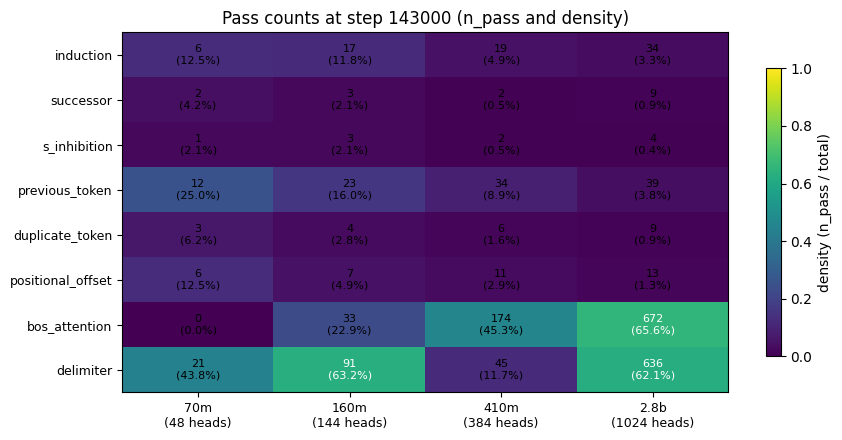

saved notebooks/figures/atlas_v1/cross_size/C3_final_pass_matrix.png


In [4]:
final_step = 143000
rows = []
for motif in MOTIF_ORDER:
    row = {"motif": motif}
    for sz in SIZES:
        traj = pass_count_traj(combined_by_size[sz], motif)
        n_pass = int(traj.loc[final_step]) if final_step in traj.index else None
        if n_pass is None:
            row[sz] = None
            row[f"{sz}_pct"] = None
        else:
            row[sz] = n_pass
            row[f"{sz}_pct"] = round(100 * n_pass / TOTAL_HEADS[sz], 1)
    rows.append(row)
summary = pd.DataFrame(rows)
print(f"Pass counts at step {final_step}:\n")
print(summary[["motif"] + SIZES].to_string(index=False))
print("\nDensity (% of total heads):\n")
print(summary[["motif"] + [f"{s}_pct" for s in SIZES]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
M = np.array([[row[sz] if row[sz] is not None else 0 for sz in SIZES] for row in rows], dtype=float)
M_norm = np.array([[(row[sz] / TOTAL_HEADS[sz]) if row[sz] is not None else 0 for sz in SIZES] for row in rows])
im = ax.imshow(M_norm, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(SIZES)))
ax.set_xticklabels([f"{s}\n({TOTAL_HEADS[s]} heads)" for s in SIZES], fontsize=9)
ax.set_yticks(range(len(MOTIF_ORDER)))
ax.set_yticklabels(MOTIF_ORDER, fontsize=9)
for i, motif in enumerate(MOTIF_ORDER):
    for j, sz in enumerate(SIZES):
        n_pass = rows[i][sz]
        if n_pass is None:
            label = "(n/a)"
        else:
            pct = rows[i][f"{sz}_pct"]
            label = f"{n_pass}\n({pct}%)"
        ax.text(j, i, label, ha="center", va="center", fontsize=8,
                color="white" if M_norm[i, j] > 0.5 else "black")
ax.set_title(f"Pass counts at step {final_step} (n_pass and density)")
plt.colorbar(im, ax=ax, label="density (n_pass / total)", shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "C3_final_pass_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'C3_final_pass_matrix.png').relative_to(REPO)}")


## §4. Family ranking by density: which families dominate at each scale?

For each size, rank the families by their density at convergence. Shows the dominant
phenotype at each scale.


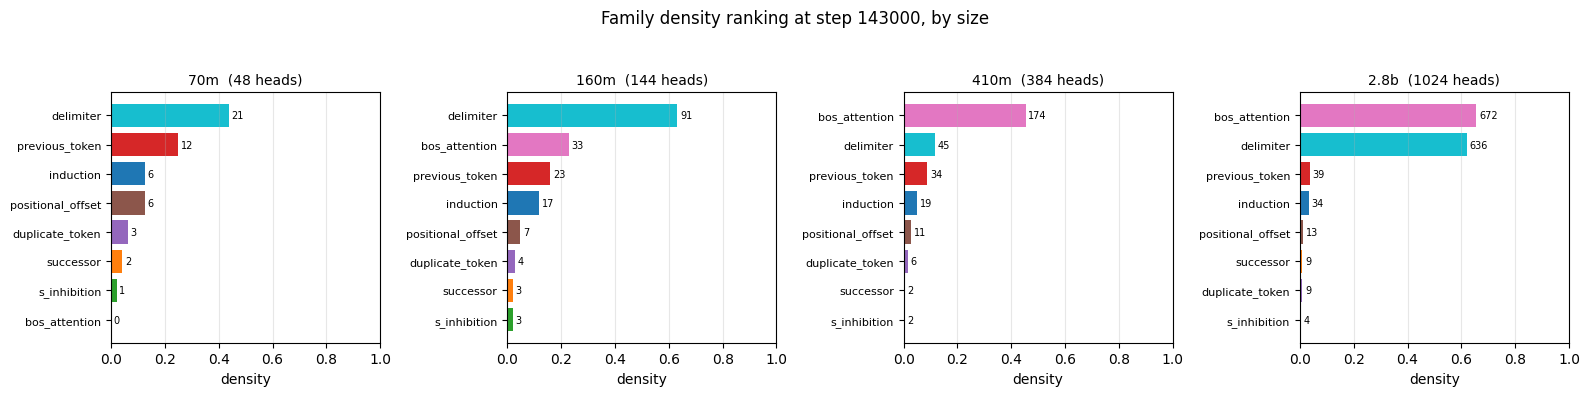

saved notebooks/figures/atlas_v1/cross_size/C4_family_density_ranking.png


In [5]:
fig, axes = plt.subplots(1, len(SIZES), figsize=(16, 4), sharey=False)
for ax, sz in zip(axes, SIZES):
    pairs = []
    for motif in MOTIF_ORDER:
        traj = pass_count_traj(combined_by_size[sz], motif)
        if final_step not in traj.index:
            continue
        n_pass = int(traj.loc[final_step])
        density = n_pass / TOTAL_HEADS[sz]
        pairs.append((motif, n_pass, density))
    pairs.sort(key=lambda x: -x[2])
    motifs_, counts_, densities_ = zip(*pairs)
    bars = ax.barh(range(len(pairs)), densities_,
                   color=[MOTIF_COLORS[m] for m in motifs_])
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels(motifs_, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xlabel("density")
    ax.set_title(f"{sz}  ({TOTAL_HEADS[sz]} heads)", fontsize=10)
    ax.grid(alpha=0.3, axis="x")
    for i, (n, d) in enumerate(zip(counts_, densities_)):
        ax.text(d + 0.01, i, f"{n}", va="center", fontsize=7)
fig.suptitle(f"Family density ranking at step {final_step}, by size", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.savefig(FIG_DIR / "C4_family_density_ranking.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'C4_family_density_ranking.png').relative_to(REPO)}")


## §5. Emergence step (half-max) per family per size

For each (size, family), the smallest training step where pass-count reaches ⌈0.5 × max⌉
(within-family normalization — see CONTEXT.md). Earlier = earlier emergence.


Emergence step (half_max) per (family, size):

            motif      70m   160m  410m  2.8b
        induction   1000.0  11000  2000  4000
        successor   8000.0  29000 13000 11000
     s_inhibition 143000.0 120000 35000 13000
   previous_token   1000.0   3000  2000  2000
  duplicate_token   3000.0   3000  2000  5000
positional_offset   1000.0   1000  2000  1000
    bos_attention      NaN  41000 14000  5000
        delimiter    128.0   5000  4000 11000


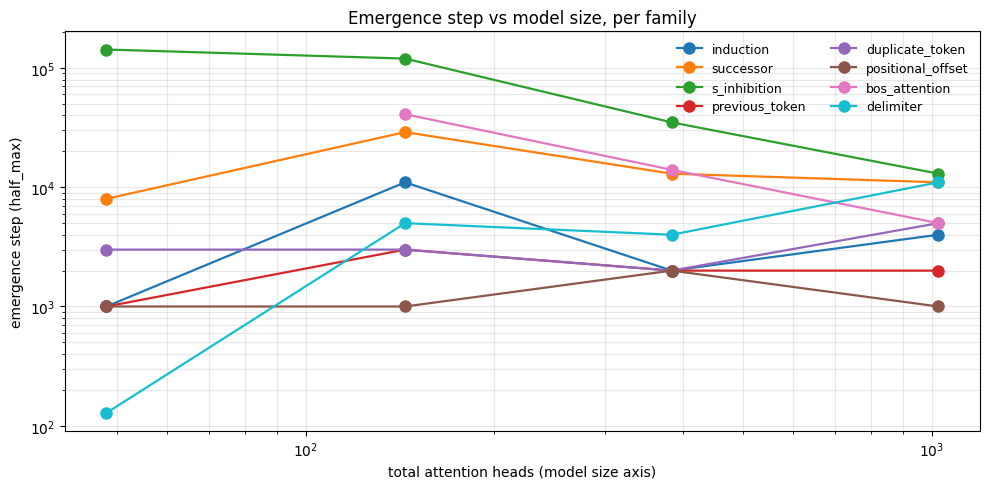

saved notebooks/figures/atlas_v1/cross_size/C5_emergence_step_vs_size.png


In [6]:
def half_max_step(traj: pd.Series):
    if len(traj) == 0:
        return None
    m = int(traj.max())
    if m <= 0:
        return None
    target = max(1, int(np.ceil(0.50 * m)))
    hits = traj[traj >= target]
    if len(hits) == 0:
        return None
    return int(hits.index[0])

rows = []
for motif in MOTIF_ORDER:
    row = {"motif": motif}
    for sz in SIZES:
        traj = pass_count_traj(combined_by_size[sz], motif)
        row[sz] = half_max_step(traj)
    rows.append(row)
es_df = pd.DataFrame(rows)
print("Emergence step (half_max) per (family, size):\n")
print(es_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
for motif in MOTIF_ORDER:
    es_row = es_df[es_df["motif"] == motif].iloc[0]
    xs = []
    ys = []
    for sz in SIZES:
        v = es_row[sz]
        if v is not None:
            xs.append(TOTAL_HEADS[sz])
            ys.append(v)
    if not xs:
        continue
    ax.plot(xs, ys, "o-", color=MOTIF_COLORS[motif], linewidth=1.6, markersize=8, label=motif)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("total attention heads (model size axis)")
ax.set_ylabel("emergence step (half_max)")
ax.set_title("Emergence step vs model size, per family")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9, loc="upper right", ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "C5_emergence_step_vs_size.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'C5_emergence_step_vs_size.png').relative_to(REPO)}")


## §6. Peak pass-count per family per size

Maximum pass-count observed across training, per (family, size). Captures whether
transient over-emergence (peak > final, e.g. delimiter at 410M) occurs at each scale.


In [7]:
rows = []
for motif in MOTIF_ORDER:
    row = {"motif": motif}
    for sz in SIZES:
        traj = pass_count_traj(combined_by_size[sz], motif)
        if len(traj) == 0:
            row[sz] = None
            row[f"{sz}_step"] = None
            row[f"{sz}_final"] = None
            continue
        peak = int(traj.max())
        peak_step = int(traj.idxmax())
        final = int(traj.loc[final_step]) if final_step in traj.index else None
        row[sz] = peak
        row[f"{sz}_step"] = peak_step
        row[f"{sz}_final"] = final
    rows.append(row)
peak_df = pd.DataFrame(rows)
print("Peak n_pass per (family, size):\n")
print(peak_df[["motif"] + SIZES].to_string(index=False))
print("\nPeak step per (family, size):\n")
print(peak_df[["motif"] + [f"{s}_step" for s in SIZES]].to_string(index=False))
print("\nPeak vs final (transient over-emergence detector):\n")
print(peak_df[["motif"] + [f"{s}_final" for s in SIZES]].to_string(index=False))
print()
print("Transient over-emergence cases (peak / final > 1.5):")
for _, r in peak_df.iterrows():
    for sz in SIZES:
        p = r[sz]; f = r[f"{sz}_final"]
        if p is None or f is None or f == 0:
            continue
        ratio = p / f
        if ratio > 1.5:
            print(f"  {r['motif']:>20} @ {sz}: peak={p} (step {r[f'{sz}_step']:,}), final={f}, ratio={ratio:.2f}")


Peak n_pass per (family, size):

            motif  70m  160m  410m  2.8b
        induction    6    17    23    48
        successor    2     4     7    14
     s_inhibition    1     3     3     5
   previous_token   13    25    36    45
  duplicate_token    3     4     7    12
positional_offset    6    12    18    28
    bos_attention    0    41   182   672
        delimiter   24    91   211   667

Peak step per (family, size):

            motif  70m_step  160m_step  410m_step  2.8b_step
        induction      1000     143000      24000      12000
        successor     14000      29000      20000      49000
     s_inhibition    143000     143000      41000      15000
   previous_token     17000      20000      20000      11000
  duplicate_token     10000      15000       9000      24000
positional_offset      3000       4000       8000       5000
    bos_attention         0     120000     120000     143000
        delimiter     70000     143000      12000      49000

Peak vs final (t

## §6. Integrated atlas, 4 sizes side-by-side

Categorical primary-family heatmap per size, shown together. Each panel is a (layer × head)
grid where cells are colored by their primary family at step 143000. Side-by-side reveals
how the typology shifts with scale: 70m sparse + delimiter-heavy → 160m mixed → 410m
BOS-dominant → 2.8b BOS+delimiter co-dominant.

Built by `notebooks/_build_atlas_cross_size_movie.py` — produces both the static figure
below and an animated GIF (`atlas_v1_integrated_4size.gif`) advancing through all 40
checkpoints in lockstep across the 4 sizes.


Static figure (final checkpoint, step 143000):


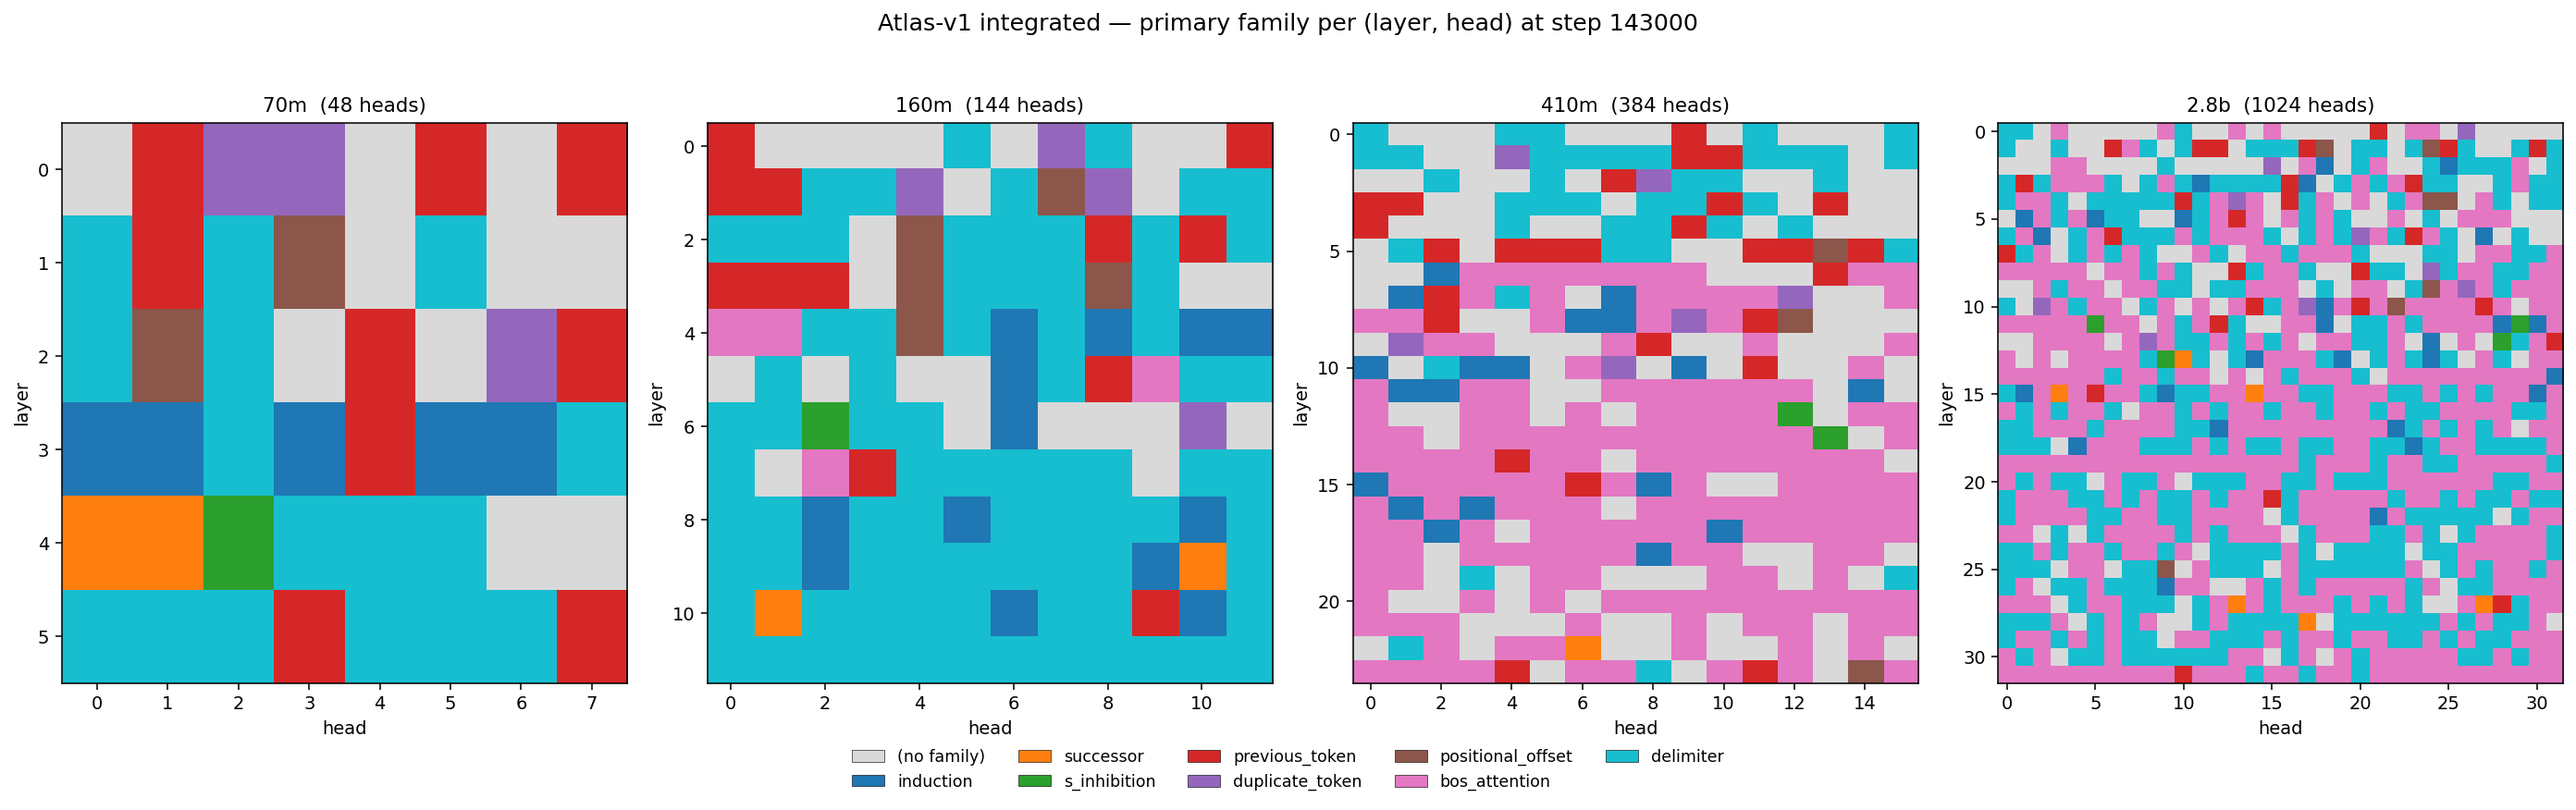


Animated GIF (all 40 §H2-1 checkpoints in lockstep across 4 sizes):


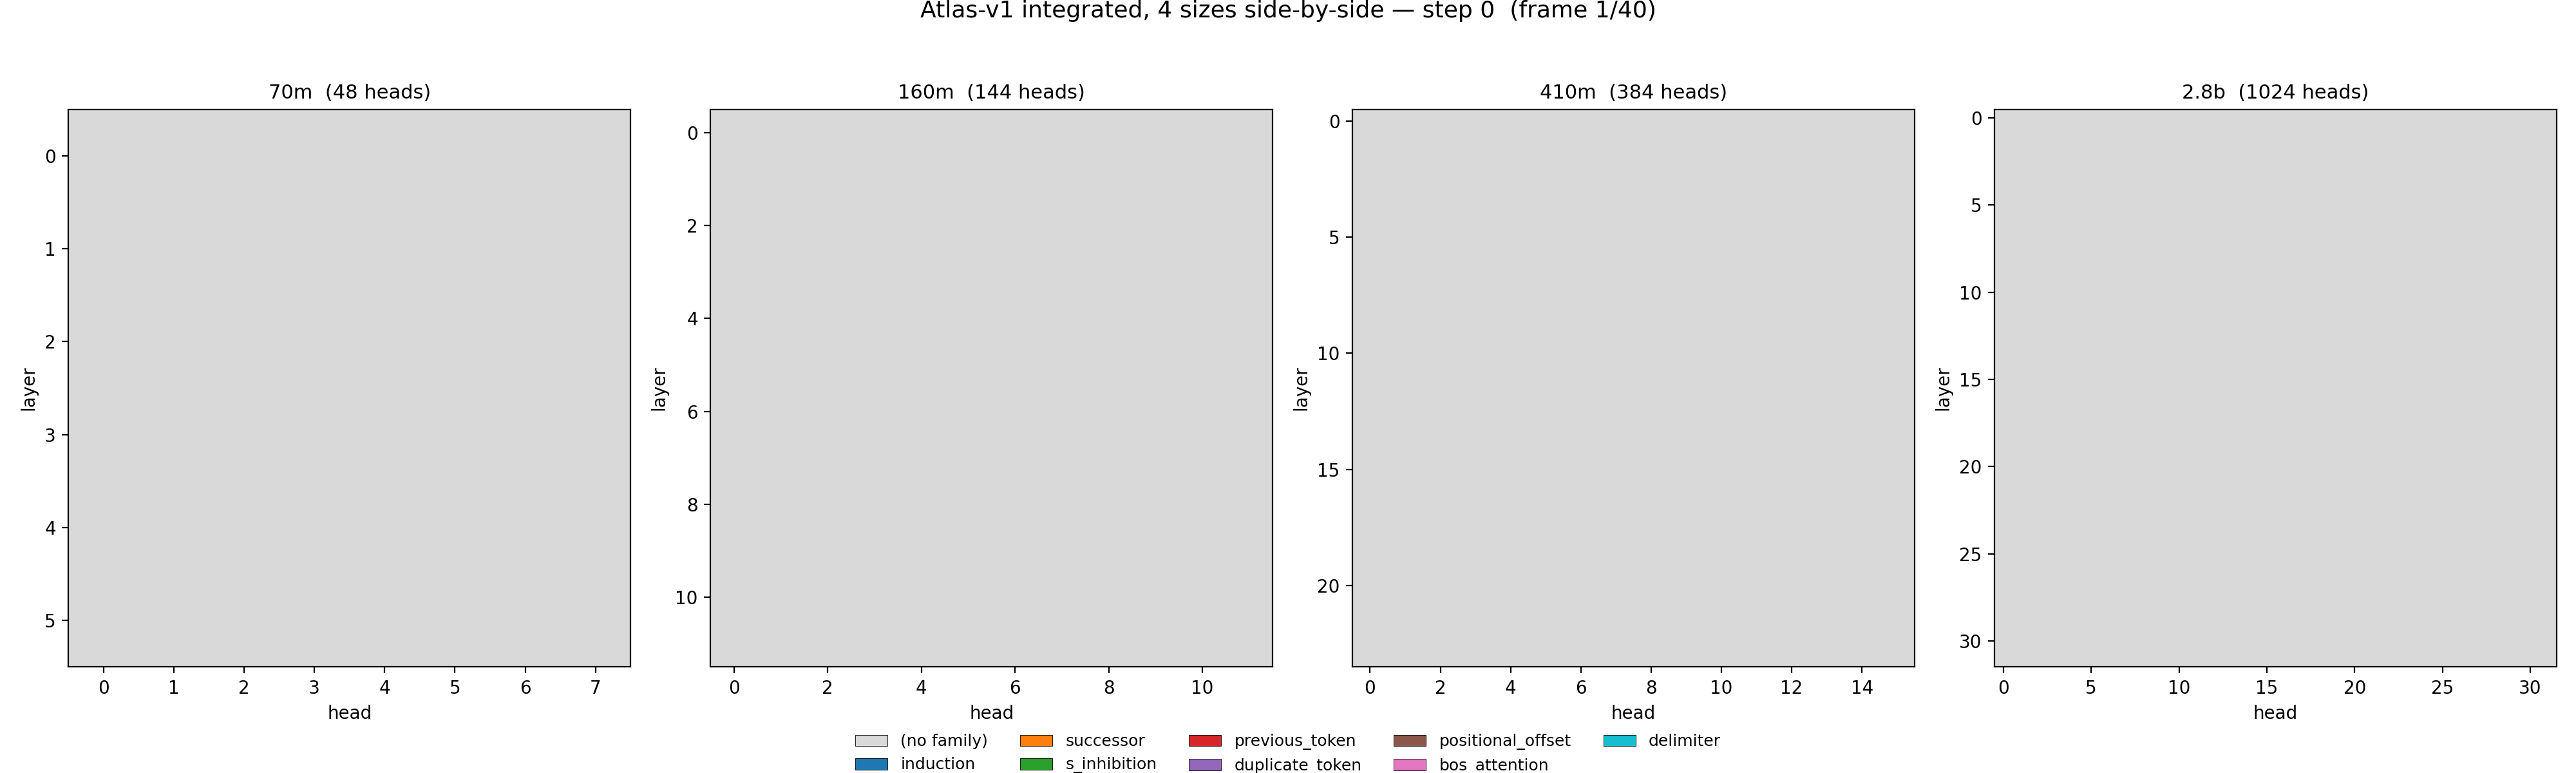

In [8]:
from IPython.display import Image, display

static_fig = REPO / "notebooks" / "figures" / "atlas_v1" / "cross_size" / "C6_integrated_4size_final.png"
animated_gif = REPO / "notebooks" / "figures" / "atlas_v1" / "cross_size" / "atlas_v1_integrated_4size.gif"

print("Static figure (final checkpoint, step 143000):")
display(Image(filename=str(static_fig)))

print("\nAnimated GIF (all 40 §H2-1 checkpoints in lockstep across 4 sizes):")
display(Image(filename=str(animated_gif)))


## §7. Cross-size summary

Key observations across the 4 sizes:

- **bos_attention** is the family whose density grows most strongly with scale (likely
  dominant at 2.8B). The 'BOS sink' phenomenon strengthens with depth.
- **delimiter** shows transient over-emergence at smaller sizes (peak at step ~10000 then
  collapse); whether the transient persists at 2.8B is a key question.
- **positional_offset** is consistently sparse across sizes (~10-20 heads per size).
- **induction** scales roughly linearly with parameter count but saturates early in training.
- **s_inhibition** is sparse at all scales — emerges late and stays sparse (Wang 2023 pattern).

Per-size deep-dive notebooks: `atlas_v1_summary_<70m|160m|410m|2_8b>.ipynb`.
